In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import random
from deepforest import main

In [2]:
model = main.deepforest(label_dict={"Penguin": 0})
model.use_bird_release()

print("Model loaded")

Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Model from BirdDetector Repo release https://github.com/weecology/BirdDetector/releases/tag/1.1 was already downloaded. Loading model from file.
Loading pre-built model: https://github.com/weecology/BirdDetector/releases/tag/1.1
Setting default score threshold to 0.3
Model loaded


In [3]:
IMAGE_DIR = Path("data/cut_moot_100m/images")
LABEL_DIR = Path("data/cut_moot_100m/labels")

image_paths = sorted(list(IMAGE_DIR.glob("*.*")))
print("Total images:", len(image_paths))

Total images: 891


In [4]:
def load_yolo_labels(label_path, image_shape):
    h, w = image_shape[:2]
    boxes = []

    if not label_path.exists():
        return np.zeros((0, 4))

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.strip().split())

            xmin = (x - bw / 2) * w
            ymin = (y - bh / 2) * h
            xmax = (x + bw / 2) * w
            ymax = (y + bh / 2) * h

            boxes.append([xmin, ymin, xmax, ymax])

    return np.array(boxes)

In [5]:
def predict_boxes(model, image_path, conf=0.2):
    df = model.predict_image(path=str(image_path))

    if df is None or len(df) == 0:
        return np.zeros((0, 4))

    if "score" in df.columns:
        df = df[df["score"] >= conf]

    if len(df) == 0:
        return np.zeros((0, 4))

    return df[["xmin", "ymin", "xmax", "ymax"]].values

In [6]:
def draw_boxes(image, boxes, color, thickness=2):
    img = image.copy()

    for (xmin, ymin, xmax, ymax) in boxes:
        cv2.rectangle(
            img,
            (int(xmin), int(ymin)),
            (int(xmax), int(ymax)),
            color,
            thickness
        )

    return img

In [7]:
def show_sample(image_path, conf=0.2):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    gt_boxes = load_yolo_labels(label_path, image.shape)
    pred_boxes = predict_boxes(model, image_path, conf)

    img_gt = draw_boxes(image, gt_boxes, (255, 0, 0))

    img_pred = draw_boxes(img_gt, pred_boxes, (0, 255, 0))

    plt.figure(figsize=(8, 8))
    plt.imshow(img_pred)
    plt.title(f"{image_path.name} | GT (red) vs Pred (green)")
    plt.axis("off")
    plt.show()

In [ ]:
def show_random_samples(n=5):
    samples = random.sample(image_paths, n)
    for p in samples:
        show_sample(p)

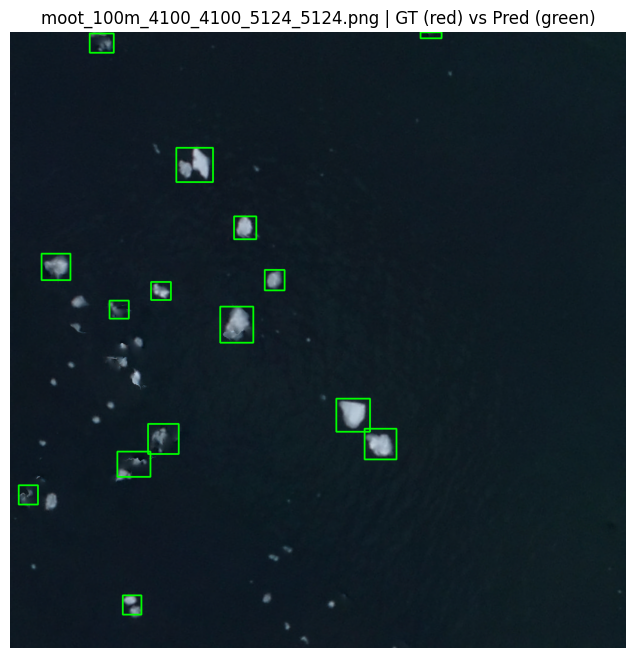

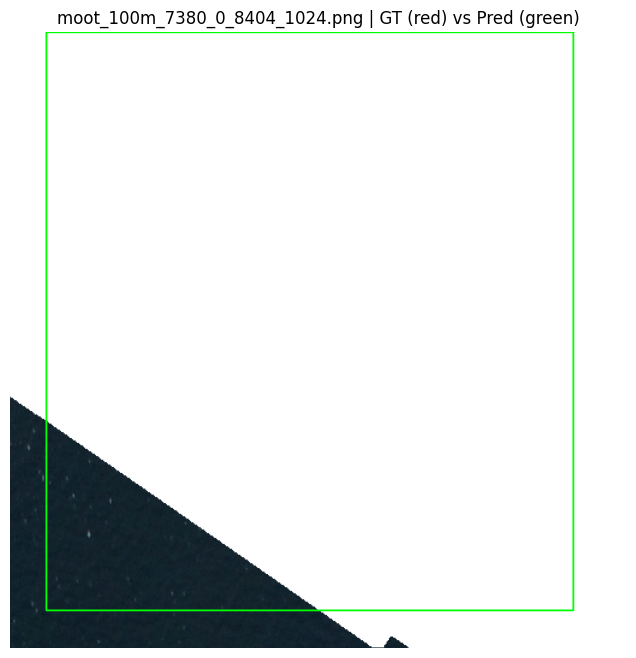

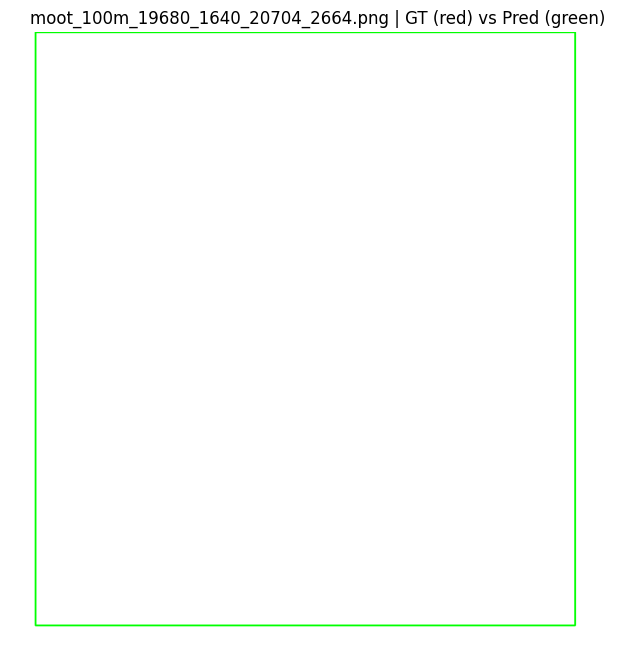

In [10]:
show_random_samples(3)

In [11]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = boxA_area + boxB_area - inter_area

    return inter_area / union if union > 0 else 0

In [12]:
def match_boxes(gt_boxes, pred_boxes, iou_thr=0.5):
    matched_gt = set()
    tp = 0

    for pred in pred_boxes:
        best_iou = 0
        best_gt_idx = -1

        for i, gt in enumerate(gt_boxes):
            if i in matched_gt:
                continue

            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i

        if best_iou >= iou_thr:
            tp += 1
            matched_gt.add(best_gt_idx)

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - len(matched_gt)

    return tp, fp, fn

In [13]:
def evaluate_dataset(conf=0.2, iou_thr=0.5):
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            continue

        label_path = LABEL_DIR / f"{image_path.stem}.txt"

        gt_boxes = load_yolo_labels(label_path, image.shape)
        pred_boxes = predict_boxes(model, image_path, conf)

        tp, fp, fn = match_boxes(gt_boxes, pred_boxes, iou_thr)

        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    print("\n===== METRICS =====")
    print("TP:", total_tp)
    print("FP:", total_fp)
    print("FN:", total_fn)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))

In [14]:
evaluate_dataset(conf=0.2, iou_thr=0.5)


===== METRICS =====
TP: 6
FP: 3571
FN: 2169
Precision: 0.0017
Recall: 0.0028
F1: 0.0021
